# Baseline Model for Animals Dataset
For the baseline model for the animals dataset, we use a convolution neural network to classify animal images as real or fake (AI-generated). In order to create the baseline model, we prepared the data, built the CNN, and trained and evaluated it with the image data.

## Table of Contents
1. [Imports and Data Upload](#imports-and-data-upload)
2. [Data Preparation](#data-preparation)
3. [Model Building](#model-building)
4. [Model Training](#model-training)
5. [Model Evaluation](#model-evaluation)
6. [Saliency Maps and Grad-CAMs](#saliency-maps-and-grad-cams)
7. [Mis-Classification by Generative Model](#mis-classification-by-generative-model)

### Imports and Data Upload

In [2]:
import sys
import os
import zipfile

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, regularizers
from sklearn.metrics import confusion_matrix, f1_score, classification_report

2025-05-07 02:09:34.216978: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-07 02:09:34.217023: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-07 02:09:34.217720: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-07 02:09:34.222738: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
if not os.path.isdir('data'):
    print("Unzipping data...")
    extract_to = "data/animals/"
    os.makedirs(extract_to, exist_ok=True)

    zip_path = "dataset_train.zip"
    with zipfile.ZipFile(zip_path) as zf:
        for zip_info in zf.infolist():
            zip_info.filename = zip_info.filename.encode('cp437').decode('utf-8', errors='replace')
            zf.extract(zip_info, extract_to)

    zip_path = "dataset_test.zip"
    with zipfile.ZipFile(zip_path) as zf:
        for zip_info in zf.infolist():
            zip_info.filename = zip_info.filename.encode('cp437').decode('utf-8', errors='replace')
            zf.extract(zip_info, extract_to)

### Data Preparation

In [3]:
def load_image_dataset(data_path, batch_size=32, img_size=(200, 200)):
    """
    load images into tensorflow dataset.

    Parameters:
        data_path (str): dataset path.
        batch_size (int): number of images to use per batch.
        img_size (tuple): image size in pixels.

    Returns:
        tf.data.Dataset object for training/testing with class names.
    """
    dataset = tf.keras.preprocessing.image_dataset_from_directory(
        data_path,
        labels='inferred',
        label_mode='binary',
        batch_size=batch_size,
        image_size=img_size,
        shuffle=True
    )

    class_names = dataset.class_names
    return dataset, class_names

In [4]:
def scale_image_dataset(dataset):
    """
    scales image dataset with helper function
    """
    def scale_img(image, label):
        """
        scales image pixel values to between [0, 1]
        """
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    return dataset.map(scale_img)

In [4]:
BATCH_SIZE = 32
img_size = (200,200)
img_height, img_width = img_size

train_data_path = "data/animals/train"
test_data_path = "data/animals/test"
weights_path = "weights"

In [6]:
train_dataset, class_names = load_image_dataset(
    train_data_path, batch_size=BATCH_SIZE, img_size=img_size
)
train_dataset = scale_image_dataset(train_dataset)

test_dataset, _ = load_image_dataset(
    test_data_path, batch_size=BATCH_SIZE, img_size=img_size
)
test_dataset = scale_image_dataset(test_dataset)

train_count = tf.data.experimental.cardinality(train_dataset).numpy()
test_count = tf.data.experimental.cardinality(test_dataset).numpy()

print(f"Number of train batches: {train_count}")
print(f"Number of test batches: {test_count}\n")

print(f"Number of train images: {train_count * BATCH_SIZE}")
print(f"Number of test images: {test_count * BATCH_SIZE}")

print(f"Class names: {class_names}")

Found 119403 files belonging to 2 classes.


2025-05-07 01:14:08.452519: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:3a:00.0, compute capability: 8.9


Found 29852 files belonging to 2 classes.
Number of train batches: 3732
Number of test batches: 933

Number of train images: 119424
Number of test images: 29856
Class names: ['fake', 'real']


### Model Building

In [6]:
model_animals = models.Sequential([
    layers.Input(shape=(img_height, img_width, 3)),

    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(256, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(512, (3, 3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(1, activation='sigmoid')
])

2025-05-07 02:10:46.560906: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 20763 MB memory:  -> device: 0, name: NVIDIA L4, pci bus id: 0000:38:00.0, compute capability: 8.9


In [7]:
model_animals.compile(
    optimizer=optimizers.Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model_animals.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 200, 200, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 200, 200, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 100, 100, 32)      0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 100, 100, 64)      18496     
                                                                 
 batch_normalization_1 (Bat  (None, 100, 100, 64)      256       
 chNormalization)                                                
                                                        

### Model Training

In [8]:
# check for existing weights
history = None
if os.path.exists(f"{weights_path}/animals_baseline_model.h5"):
    print("Loading existing model weights...")
    model_animals.load_weights(f"{weights_path}/animals_baseline_model.h5")
else:
    epochs=10
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    )
    
    lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5
    )
    
    history = model_animals.fit(
        train_dataset,
        validation_data=test_dataset,
        epochs=epochs,
        callbacks=[early_stopping, lr_scheduler]
    )

    model_animals.save(f"{weights_path}/animals_baseline_model.h5")

Loading existing model weights...


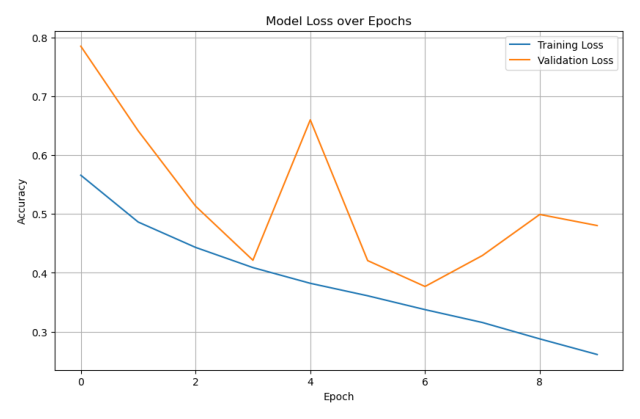

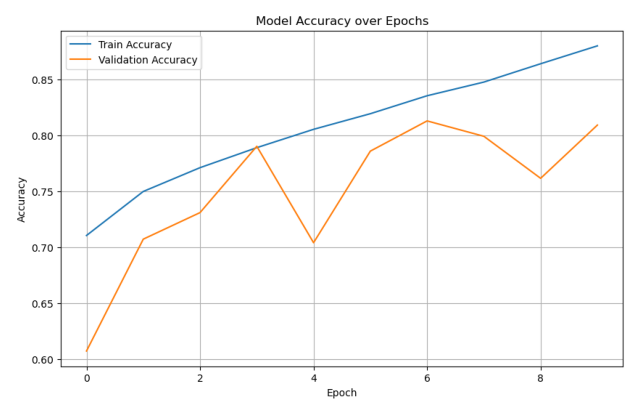

In [11]:
if history:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    
    ax1.plot(history.history['accuracy'], label='Train Accuracy')
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
    ax1.set_title('Model Accuracy')
    ax1.set_ylabel('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.grid()
    ax1.legend()
    
    ax2.plot(history.history['loss'], label='Train Loss')
    ax2.plot(history.history['val_loss'], label='Validation Loss')
    ax2.set_title('Model Loss')
    ax2.set_ylabel('Loss')
    ax2.set_xlabel('Epoch')
    ax2.grid()
    ax2.legend(['Train', 'Validation'], loc='upper right')
    
    plt.tight_layout()
    plt.show()
else:
    history_image_path1 = "loss.png"
    history_image_path2 = "accuracy.png"
    
    # show image 
    plt.figure(figsize=(8, 8))
    img = plt.imread(history_image_path1)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    # show image 
    plt.figure(figsize=(8, 8))
    img = plt.imread(history_image_path2)
    plt.imshow(img)
    plt.axis('off')
    plt.show()

    

### Model Evaluation

In [11]:
loss, accuracy = model_animals.evaluate(test_dataset)
print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")

2025-05-07 01:14:34.255019: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8907


933/933 [==============================] - 16s 16ms/step - loss: 0.3897 - accuracy: 0.8023
Test Loss: 0.3897, Test Accuracy: 0.8023


In [12]:
y_true = np.concatenate([y for x, y in test_dataset], axis=0)
y_pred_probs = model_animals.predict(test_dataset)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()

cm = confusion_matrix(y_true, y_pred)

f1 = f1_score(y_true, y_pred)

print(f"Test Loss: {loss:.4f}, Test Accuracy: {accuracy:.4f}")
print(f"Test F1 Score: {f1:.4f}")
print("Confusion Matrix:")
print(cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=class_names))

933/933 [==============================] - 13s 14ms/step
Test Loss: 0.3897, Test Accuracy: 0.8023
Test F1 Score: 0.5817
Confusion Matrix:
[[ 5249  7016]
 [ 7497 10090]]

Classification Report:
              precision    recall  f1-score   support

        fake       0.41      0.43      0.42     12265
        real       0.59      0.57      0.58     17587

    accuracy                           0.51     29852
   macro avg       0.50      0.50      0.50     29852
weighted avg       0.52      0.51      0.52     29852



### Saliency Maps and Grad-CAMs

In [35]:
def get_sample_images(dataset, num_samples=5):
    """
    Get sample images from dataset for visualization
    """
    sample_images = []
    sample_labels = []
    class_counts = {0: 0, 1: 0}  
    
    for images, labels in dataset:
        for i in range(len(images)):
            img = images[i].numpy()
            label = int(labels[i].numpy())
            
            if class_counts[label] < num_samples:
                sample_images.append(img)
                sample_labels.append(label)
                class_counts[label] += 1
        
        if min(class_counts.values()) >= num_samples:
            break
    
    return sample_images, sample_labels

def plot_gradcam(model, image, class_index, last_conv_layer_name, alpha=0.4):
    """
    Generates and plots a Grad-CAM heatmap for a given image and class.

    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels). 
               The image should be preprocessed (e.g., normalized) as needed.
        class_index: Integer index of the target class to visualize.
        last_conv_layer_name: String, name of the last convolutional layer in the model.
        alpha: Float, transparency factor for the heatmap overlay.
    """
    img_tensor = np.expand_dims(image, axis=0)

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, class_index]

    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()

    heatmap = np.uint8(255 * heatmap)
    heatmap = tf.image.resize(np.expand_dims(
        heatmap, axis=-1), (image.shape[0], image.shape[1])).numpy()
    heatmap = np.squeeze(heatmap)

    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].imshow(image)
    ax[0].set_title('Original imege')
    ax[0].axis('off')
    ax[1].imshow(image)
    ax[1].imshow(heatmap, cmap='jet', alpha=alpha)
    ax[1].set_title('Grad-CAM heatmap')
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()

def compute_saliency_map(model, image, target_class=0):
    """
    Computes the saliency map for the given image and target class.
    Args:
        model: Trained Keras model.
        image: Input image as a NumPy array of shape (height, width, channels).
               Assumed to be preprocessed (e.g., normalized) as required by the model.
        target_class: Integer index for the target class (0 for 'fake', 1 for 'real').
    Returns:
        A NumPy array representing the saliency map.
    """
    img_tensor = tf.expand_dims(image, axis=0)
    img_tensor = tf.cast(img_tensor, tf.float32)
    
    with tf.GradientTape() as tape:
        tape.watch(img_tensor)
        preds = model(img_tensor)
        score = preds if target_class == 1 else 1 - preds
        
    grads = tape.gradient(score, img_tensor)
    saliency = tf.reduce_max(tf.abs(grads), axis=-1)[0]
    return saliency.numpy()

def display_saliency_map(model, image, target_class=0):
    """
    Computes and displays the saliency map alongside the original image.
    
    Args:
        model: Trained Keras model.
        image: A single input image as a NumPy array.
        target_class: The index of the target class.
    """
    saliency = compute_saliency_map(model, image, target_class)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(image)
    plt.title("Original image")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(saliency, cmap='jet')
    plt.title("Saliency map")
    plt.axis("off")

    plt.show()

def get_predictions_and_labels(dataset, model):
    y_pred = []
    y_true = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        pred_classes = (predictions > 0.5).astype(int)
        
        y_pred.extend(pred_classes.flatten())
        y_true.extend(labels.numpy())
    
    return np.array(y_pred), np.array(y_true)


def get_probabilities_and_labels(dataset, model):
    y_prob = []
    y_true = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        
        y_prob.extend(predictions.flatten())
        y_true.extend(labels.numpy())
    
    return np.array(y_prob), np.array(y_true)

def visualize_single_image(model, img, last_conv_layer_name, actual_class):
    """
    Visualize a single image with both Grad-CAM and Saliency Map
    """
    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    
    # Original image
    ax[0].imshow(img)
    ax[0].set_title(f"{'Real' if actual_class==1 else 'Fake'} Animal Image")
    ax[0].axis('off')
    
    # Saliency Map
    saliency = compute_saliency_map(model, img, target_class=actual_class)
    ax[1].imshow(saliency, cmap='jet')
    ax[1].set_title("Saliency Map")
    ax[1].axis('off')
    
    # Grad-CAM
    ax[2].imshow(img)
    
    # Compute Grad-CAM
    img_tensor = np.expand_dims(img, axis=0)
    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        pred_prob = predictions[0][0].numpy()
        pred_class = 1 if pred_prob > 0.5 else 0
        loss = predictions[:, 0] if actual_class == 0 else 1 - predictions[:, 0]
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    
    # Overlay heatmap
    ax[2].imshow(heatmap, cmap='jet', alpha=0.4)
    ax[2].set_title(f"Grad-CAM (Pred: {'Real' if pred_class==1 else 'Fake'}, {pred_prob:.2f})")
    ax[2].axis('off')
    
    plt.tight_layout()
    plt.show()

def find_interesting_examples(dataset, model, num_samples=5):
    """
    Find examples where the model is very confident or misclassified
    Used for GRAD-Cam and Saliency map
    """
    correct_confident = []
    incorrect = []
    unsure = []
    
    for images, labels in dataset:
        predictions = model.predict(images, verbose=0)
        
        for i in range(len(images)):
            img = images[i].numpy()
            true_label = int(labels[i].numpy())
            pred_prob = predictions[i][0]
            pred_label = 1 if pred_prob > 0.5 else 0
            
            if pred_label == true_label:
                if pred_prob > 0.95 or pred_prob < 0.05:  # this is the confident prediction
                    correct_confident.append((img, true_label, pred_prob))
            else:  # these are the misclassified
                incorrect.append((img, true_label, pred_prob))
            
            # unsure predictions
            if 0.4 < pred_prob < 0.6:
                unsure.append((img, true_label, pred_prob))
        
        if len(correct_confident) >= num_samples and len(incorrect) >= num_samples and len(unsure) >= num_samples:
            break
    
    return correct_confident, incorrect, unsure

/tmp/ipykernel_41195/2159359084.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  label = int(labels[i].numpy())


Last convolutional layer name: conv2d_4


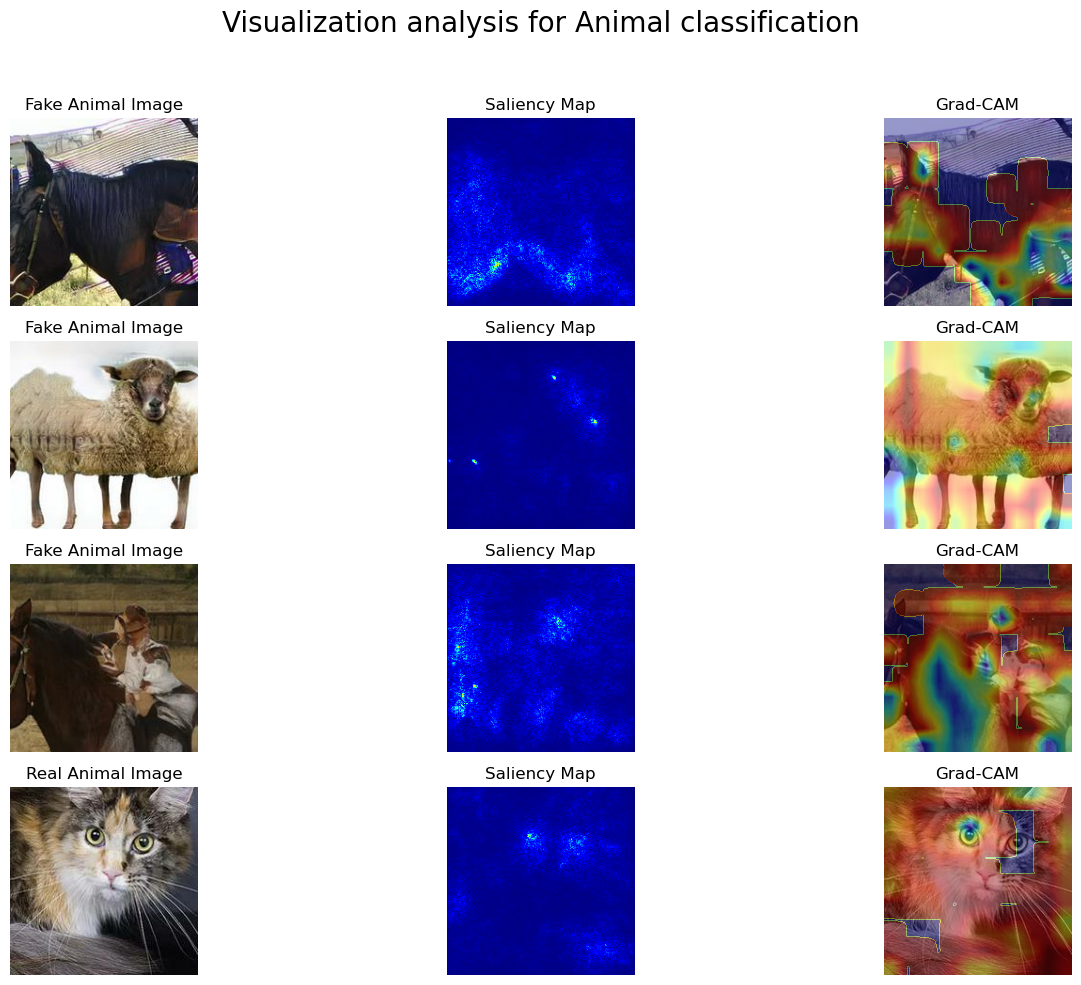

In [30]:
import cv2

sample_images, sample_labels = get_sample_images(test_dataset, num_samples=5)

# we need to extract the name from the model
last_conv_layer_name = None
for layer in model_animals.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv_layer_name = layer.name

print(f"Last convolutional layer name: {last_conv_layer_name}")

# Grad-CAM and Saliency maps 
plt.figure(figsize=(15, 10))
plt.suptitle("Visualization analysis for Animal classification", fontsize=20)

for i, (img, label) in enumerate(zip(sample_images[:4], sample_labels[:4])):
    # original image
    plt.subplot(4, 3, i*3+1)
    plt.imshow(img)
    plt.title(f"{'Real' if label==1 else 'Fake'} Animal Image")
    plt.axis('off')
    
    # Saliency map
    saliency = compute_saliency_map(model_animals, img, target_class=label)
    plt.subplot(4, 3, i*3+2)
    plt.imshow(saliency, cmap='jet')
    plt.title("Saliency Map")
    plt.axis('off')
    
    # Grad-CAM
    plt.subplot(4, 3, i*3+3)
    plt.imshow(img)
    
    # Grad-CAM heatmap
    img_tensor = np.expand_dims(img, axis=0)
    grad_model = tf.keras.models.Model(
        inputs=model_animals.inputs,
        outputs=[model_animals.get_layer(last_conv_layer_name).output, model_animals.output]
    )
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)
        loss = predictions[:, 0] 
    
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    heatmap = heatmap.numpy()
    heatmap = np.uint8(255* heatmap)
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    
    # use an overlay heatmap on the original image
    plt.imshow(heatmap, cmap='jet', alpha=0.4)
    plt.title("Grad-CAM")
    plt.axis('off')

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

/tmp/ipykernel_41195/498680700.py:211: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  true_label = int(labels[i].numpy())


Found 25 confident correct predictions
Found 13 incorrect predictions
Found 6 uncertain predictions

Visualizing incorrect predictions:


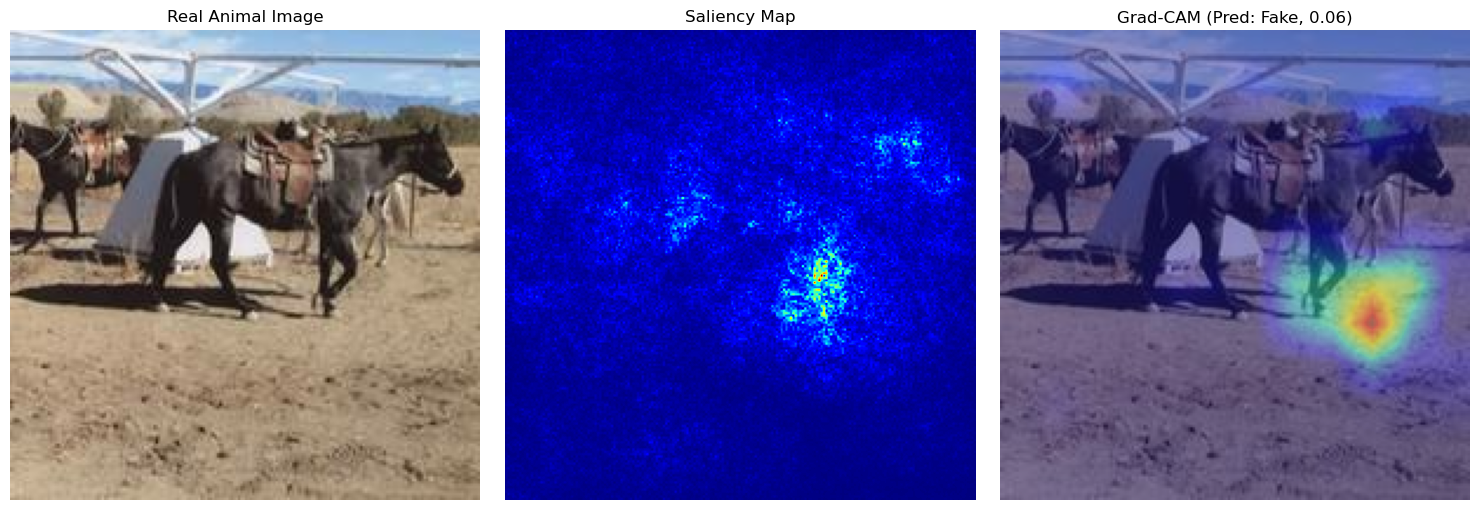

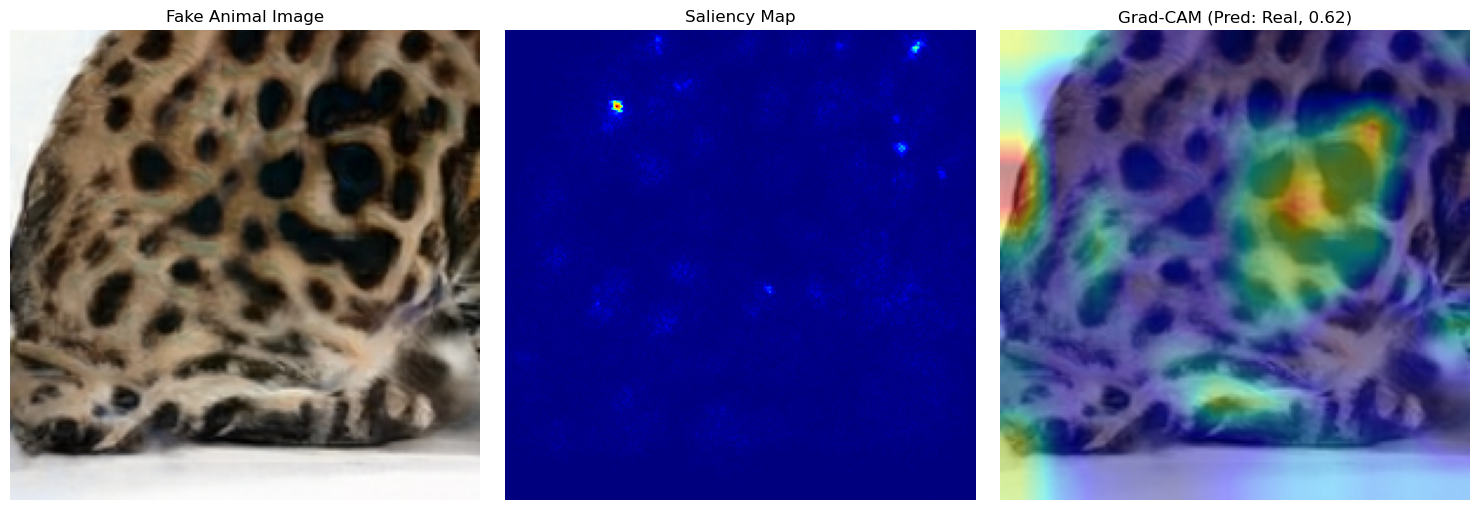


Visualizing uncertain predictions:


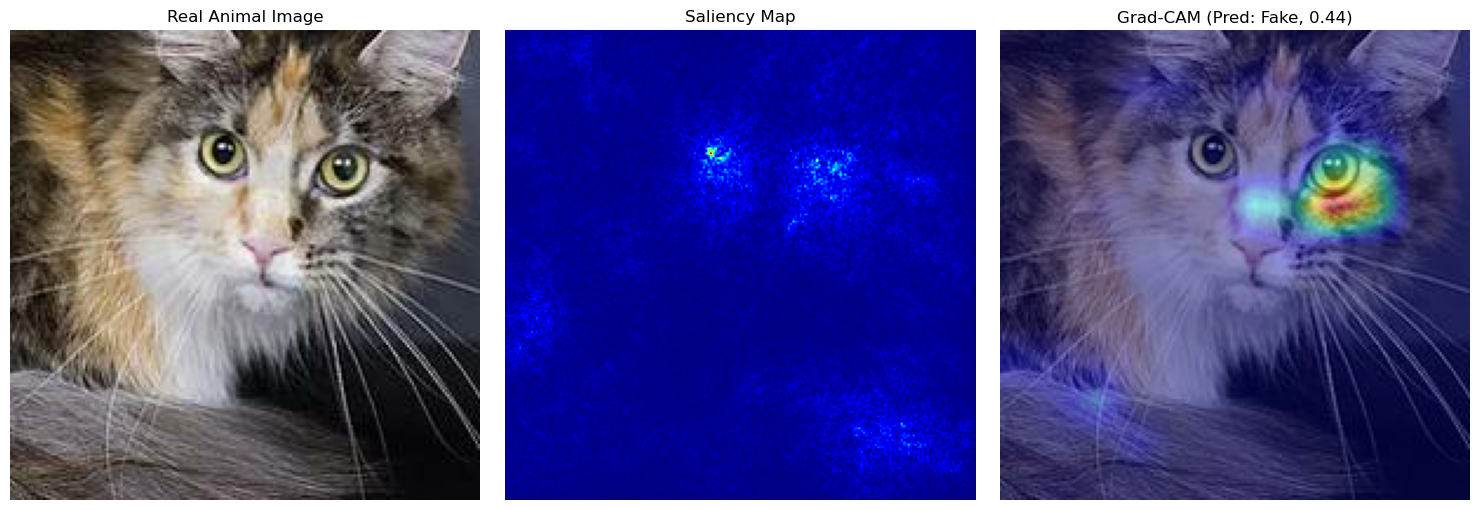

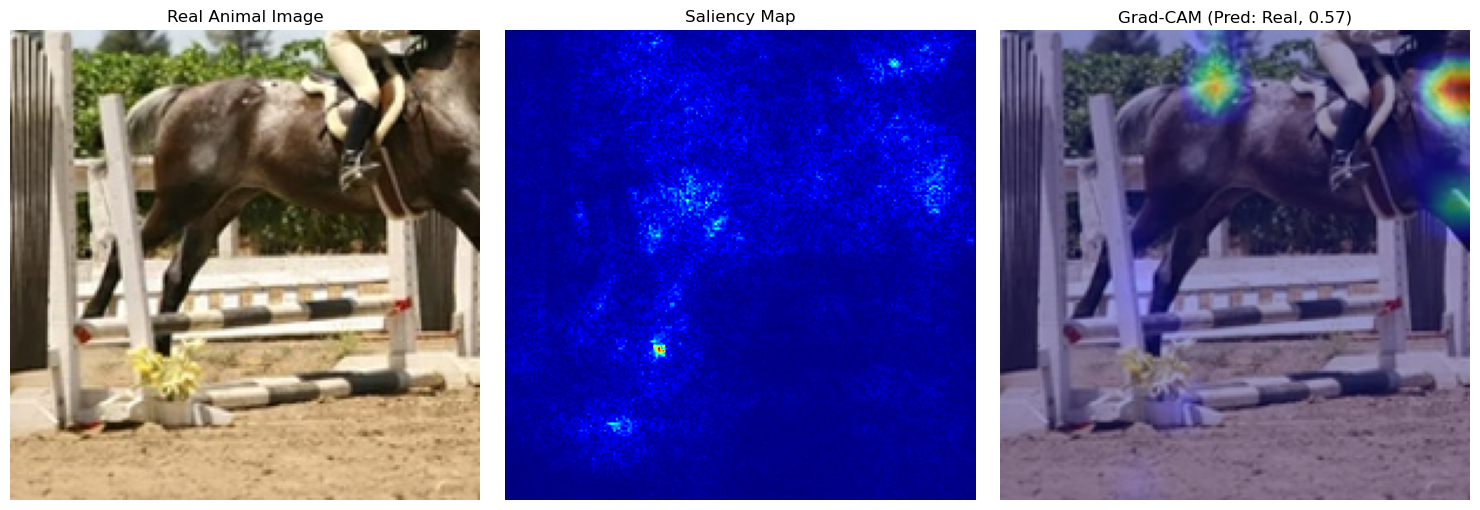

In [36]:
# get misclassified and confident predictions
correct_confident, incorrect, unsure = find_interesting_examples(test_dataset, model_animals)

print(f"Found {len(correct_confident)} confident correct predictions")
print(f"Found {len(incorrect)} incorrect predictions")
print(f"Found {len(unsure)} uncertain predictions")

# plot
print("\nVisualizing incorrect predictions:")
for img, true_label, pred_prob in incorrect[:2]:
    visualize_single_image(model_animals, img, last_conv_layer_name, true_label)

print("\nVisualizing uncertain predictions:")
for img, true_label, pred_prob in unsure[:2]:
    visualize_single_image(model_animals, img, last_conv_layer_name, true_label)

### Mis-Classification by Generative Model

In [13]:
if not os.path.isdir('fake_imgs'):
    print("Unzipping data...")
    extract_to = "fake_imgs"
    os.makedirs(extract_to, exist_ok=True)

    zip_path = "fake_by_model.zip"
    with zipfile.ZipFile(zip_path) as zf:
        for zip_info in zf.infolist():
            zip_info.filename = zip_info.filename.encode('cp437').decode('utf-8', errors='replace')
            zf.extract(zip_info, extract_to)

In [14]:
raw_root = 'fake_imgs/fake'
test_root = 'data/animals/test/fake'
output_dir = '.'
os.makedirs(output_dir, exist_ok=True)

In [15]:
test_files = set(os.listdir(test_root))
print(f"Test files: {len(test_files)}") 

Test files: 12265


In [16]:
from collections import defaultdict
from typing import Counter
from PIL import Image

counts = defaultdict(Counter)

for AI_model in os.listdir(raw_root):
    print(f"Processing model: {AI_model}")
    model_dir = os.path.join(raw_root, AI_model)
    if not os.path.isdir(model_dir):
        continue

    # find intersection of raw-generated files and test set
    raw_files = set(os.listdir(model_dir))
    intersect_files = sorted(raw_files & test_files)

    predictions = []
    print(f"Found {len(intersect_files)} files in intersection")
    for fname in intersect_files:
        try:
            img = Image.open(os.path.join(test_root, fname)).convert('RGB')
            arr = np.array(img) / 255.0
            arr = np.expand_dims(arr, 0)

            preds = model_animals.predict(arr, verbose=0)
            if preds.shape[-1] == 1:
                pred = int(preds[0][0] > 0.5)
            else:
                pred = int(np.argmax(preds, axis=1)[0])

            counts[AI_model][pred] += 1

        except Exception as e:
            print(f"Error on {fname}: {e}")

Processing model: pro_gan
Found 1158 files in intersection
Processing model: style_gan
Found 10000 files in intersection
Processing model: cycle_gan
Found 1056 files in intersection


In [17]:
models = sorted(counts.keys())
rows = []
for model in models:
    total = sum(counts[model].values())
    misclassified = counts[model].get(1, 0)
    rows.append(
        {'model': model, 'misclassified': misclassified, 'total': total, 'percentage': f"{misclassified / total * 100:.2f}%"})
    
# order by misclassified
rows.sort(key=lambda x: x['percentage'], reverse=True)

# add rank
for i, row in enumerate(rows):
    row['rank'] = i + 1

df = pd.DataFrame(rows)
df

,model,misclassified,total,percentage,rank
0,pro_gan,543,1158,46.89%,1
1,style_gan,2447,10000,24.47%,2
2,cycle_gan,133,1056,12.59%,3
